In [1]:
#%pip install VESIcal # you need this to run the saturation pressure calcs. Make sure they restart the kernel and comment this again, else it seems to bug out PetThermoTools

In [2]:
# import core python packages that we'll use for plotting and data manipulation.
import sys
import os
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
import petthermotools as ptt 
import VESIcal as v

alphaMELTS for Python files successfully located.


c:\Users\penny\anaconda3\Lib\site-packages\VESIcal\calculate_classes.py:7: UserWarning: 

  from VESIcal.models import magmasat


In [3]:
ptt.__version__

'0.3.20'

In [4]:
# Lets see what models we have - you wont be able to run magmasat. 
v.get_model_names()

['ShishkinaIdealMixing',
 'Dixon',
 'IaconoMarziano',
 'Liu',
 'ShishkinaCarbon',
 'ShishkinaWater',
 'DixonCarbon',
 'DixonWater',
 'IaconoMarzianoCarbon',
 'IaconoMarzianoWater',
 'AllisonCarbon',
 'AllisonCarbon_sunset',
 'AllisonCarbon_sfvf',
 'AllisonCarbon_erebus',
 'AllisonCarbon_vesuvius',
 'AllisonCarbon_etna',
 'AllisonCarbon_stromboli',
 'MooreWater',
 'LiuWater',
 'LiuCarbon']

## Q1 - lets gain some intuition as to how much volatiles we can dissolve in a given magma using different models

In [5]:
# Lets load the major elements for 1 sample - This is a melt inclusion from Kilauea
kilauea = v.Sample({'SiO2':  48.42,
                    'TiO2':   2.45,
                    'Al2O3': 11.90,
                    'Fe2O3':  0.00,
                    'FeO':   11.33,
                    'MgO':   12.51,
                    'CaO':   10.02,
                    'Na2O':   2.10,
                    'K2O':    0.45,
                    'P2O5':   0.30,
                    })
# Pressure in bars, T in celcius, XFluid, 1 is all H2O, 0 is all CO2
calc_IM = v.calculate_dissolved_volatiles(sample=kilauea, 
                                       pressure=1000, 
                                       temperature=1200, 
                                       X_fluid=0.05,
                                      model='IaconoMarziano')
calc_IM.result

{'H2O_liq': 0.7540099313023552, 'CO2_liq': 0.056696649828960936}

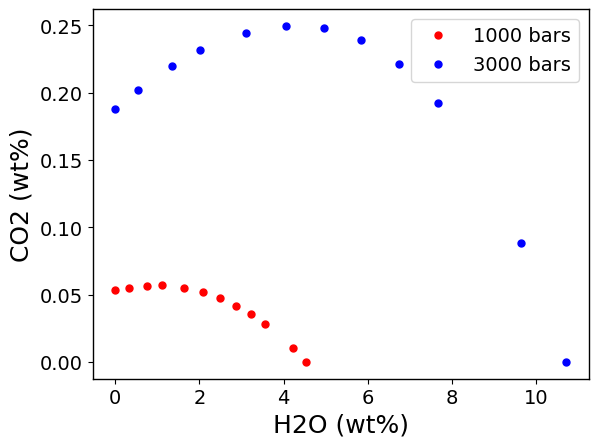

In [6]:
for i, Xfluid in enumerate([0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1]):
    calc_IM = v.calculate_dissolved_volatiles(sample=kilauea, 
                                       pressure=1000, 
                                       temperature=1200, 
                                       X_fluid=Xfluid,
                                      model='IaconoMarziano')
    plt.plot(calc_IM.result['H2O_liq'], calc_IM.result['CO2_liq'], '.r', label='1000 bars'  if i == 0 else None)

    calc_IM_3000 = v.calculate_dissolved_volatiles(sample=kilauea, 
                                       pressure=3000, 
                                       temperature=1200, 
                                       X_fluid=Xfluid,
                                      model='IaconoMarziano')
    plt.plot(calc_IM_3000.result['H2O_liq'], calc_IM_3000.result['CO2_liq'], '.b', label='3000 bars'  if i == 0 else None)
    plt.xlabel('H2O (wt%)')
    plt.ylabel('CO2 (wt%)')
    plt.legend()

c:\Users\penny\anaconda3\Lib\site-packages\VESIcal\calculate_classes.py:60: RuntimeWarning: pressure exceeds 1000 bar, which Iacono-Marziano et al. (2012) suggest as an upper calibration limit of the Dixon (1997, Pi-SiO2 simpl.) Model, as well as the upper calibration limit of 2000 bar suggested by Lesne et al. (2011), 
  w.warn(self.calib_check, RuntimeWarning)
c:\Users\penny\anaconda3\Lib\site-packages\VESIcal\calculate_classes.py:60: RuntimeWarning: pressure exceeds 1000 bar, which Iacono-Marziano et al. (2012) suggest as an upper calibration limit of the Dixon (1997, Pi-SiO2 simpl.) Model, as well as the upper calibration limit of 2000 bar suggested by Lesne et al. (2011), 
  w.warn(self.calib_check, RuntimeWarning)
c:\Users\penny\anaconda3\Lib\site-packages\VESIcal\calculate_classes.py:60: RuntimeWarning: pressure exceeds 1000 bar, which Iacono-Marziano et al. (2012) suggest as an upper calibration limit of the Dixon (1997, Pi-SiO2 simpl.) Model, as well as the upper calibration l

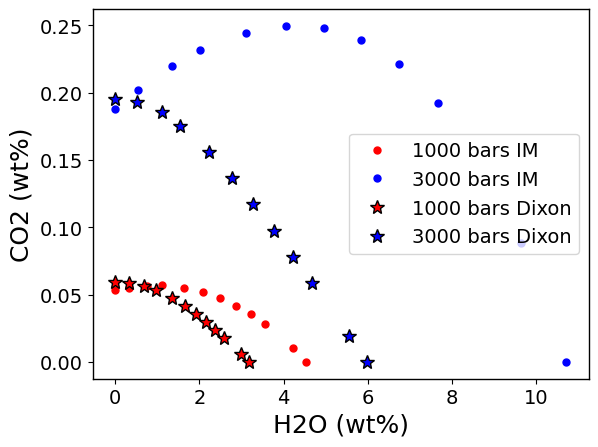

In [7]:
for i, Xfluid in enumerate([0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.9, 1]):
    calc_IM = v.calculate_dissolved_volatiles(sample=kilauea, 
                                       pressure=1000, 
                                       temperature=1200, 
                                       X_fluid=Xfluid,
                                      model='IaconoMarziano')
    plt.plot(calc_IM.result['H2O_liq'], calc_IM.result['CO2_liq'], '.r', label='1000 bars IM'  if i == 0 else None)

    calc_IM_3000 = v.calculate_dissolved_volatiles(sample=kilauea, 
                                       pressure=3000, 
                                       temperature=1200, 
                                       X_fluid=Xfluid,
                                      model='IaconoMarziano')
    plt.plot(calc_IM_3000.result['H2O_liq'], calc_IM_3000.result['CO2_liq'], '.b', label='3000 bars IM'  if i == 0 else None)

    ## Dixon

    calc_Dix = v.calculate_dissolved_volatiles(sample=kilauea, 
                                       pressure=1000, 
                                       temperature=1200, 
                                       X_fluid=Xfluid,
                                      model='Dixon')
    plt.plot(calc_Dix.result['H2O_liq'], calc_Dix.result['CO2_liq'], '*k', mfc='red', label='1000 bars Dixon'  if i == 0 else None)

    calc_Dix_3000 = v.calculate_dissolved_volatiles(sample=kilauea, 
                                       pressure=3000, 
                                       temperature=1200, 
                                       X_fluid=Xfluid,
                                      model='Dixon')
    plt.plot(calc_Dix_3000.result['H2O_liq'], calc_Dix_3000.result['CO2_liq'], '*k', mfc='blue', label='3000 bars Dixon'  if i == 0 else None)


    plt.xlabel('H2O (wt%)')
    plt.ylabel('CO2 (wt%)')
    plt.legend()

## Question 2- Lets look what happens as we decompress a magma 
- We will be using PetThermoTools, so run on VICTOR if you havent installed locally!

In [8]:
# Check the version
import petthermotools as ptt
ptt.__version__

'0.3.20'

In [9]:
## If using Mac run this cell **twice** 
import platform
if platform.system() == "Darwin" or platform.system() == "Linux":
    sys.stdout = open(os.devnull, 'w')
    sys.stderr = open(os.devnull, 'w')

In [10]:
# PetThermoTools has a slightly different input structure to VESIcal - input as a dictionary, not a custom data type
kilauea_primary = {'SiO2_Liq':  48.42,
                    'TiO2_Liq':   2.45,
                    'Al2O3_Liq': 11.90,
                    'Fe2O3_Liq':  2,
                    'FeO_Liq':   10,
                    'MgO_Liq':   12.51,
                    'CaO_Liq':   10.02,
                    'Na2O_Liq':   2.10,
                    'K2O_Liq':    0.45,
                    'P2O5_Liq':   0.30,
                    'H2O_Liq':0.5, 
                    'CO2_Liq': 5000/10**4
                    }

### now decompress it

In [11]:

Kil_decompress = ptt.isothermal_decompression(Model = "MELTSv1.2.0", # rhyolite-MELTS v1.2.0 - updated H2O-CO2 solubility model - This is 'Magmasat' from the lectures
                                            bulk = kilauea_primary, # composition defined above is our starting composition
                                            find_liquidus=True, # specify that we want to start at the liquidus 
                                            fO2_buffer="FMQ", # Impose a fO2 buffer
                                            P_start_bar=10000, # starting pressure (in bars)
                                            P_end_bar=1000, # final pressure (in bars)
                                            dp_bar=20) # pressure step (in bars)


A default timeout of 5 minutes has been specified. If you are not getting any results try increasing this using the timeout kwarg.
Running MELTSv1.2.0 calculation...

 Complete (time taken = 27.38 seconds)

## 2a

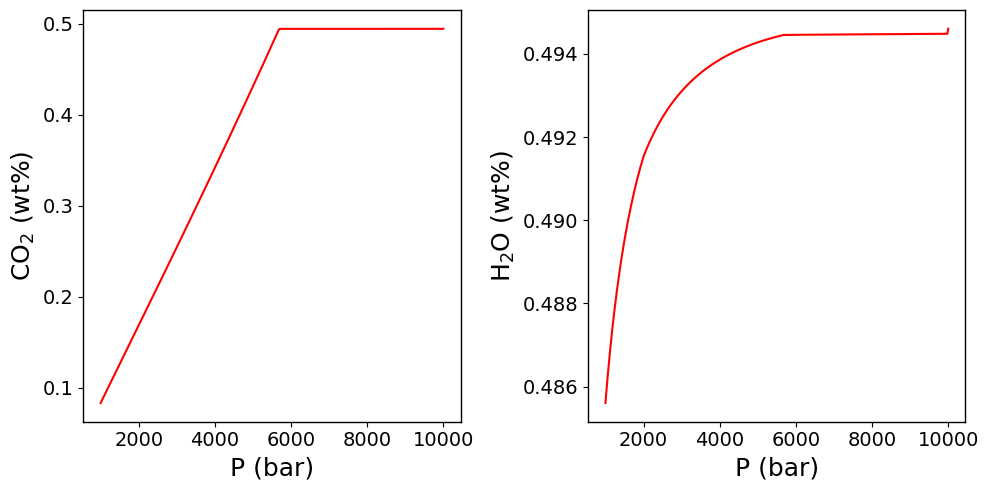

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.plot(Kil_decompress['All']['P_bar'], Kil_decompress['All']['CO2_Liq'], '-r')
ax2.plot(Kil_decompress['All']['P_bar'], Kil_decompress['All']['H2O_Liq'], '-r')
ax1.set_xlabel('P (bar)')
ax2.set_xlabel('P (bar)')

ax1.set_ylabel('CO$_2$ (wt%)')
ax2.set_ylabel('H$_2$O (wt%)')
plt.tight_layout()

### 2c

In [ ]:
Kil_decompress['fluid1']

### 2e

Text(0, 0.5, 'XH2O')

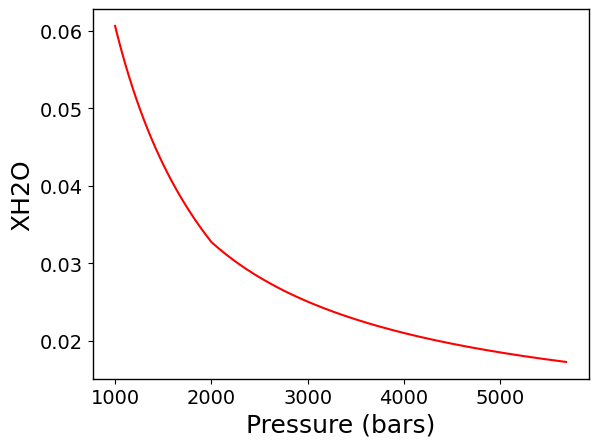

In [13]:
plt.plot(Kil_decompress['All']['P_bar'], Kil_decompress['All']['X_H2O_mol_Fl'], '-r')
plt.xlabel('Pressure (bars)')
plt.ylabel('XH2O')

## 3. Now lets let this magma start to fractionally crystallize after ascending into the main crustal magma storage reservoir

In [15]:
start_comp_after_ascent=Kil_decompress['liquid1'].iloc[-1] # this grabs the last value after the ascent calculation. 

In [16]:
Isobaric_Xtal = ptt.isobaric_crystallisation(Model = "MELTSv1.2.0",
                                           bulk = dict(start_comp_after_ascent),
                                           find_liquidus = True,
                                           P_bar = 1000,
                                           T_end_C = 1050,
                                           dt_C = 2,
                                           fO2_buffer = "FMQ",
                                           fO2_offset = +0.4,
                                           Frac_solid = True,
                                           Frac_fluid = True,
                                          )

A default timeout of 5 minutes has been specified. If you are not getting any results try increasing this using the timeout kwarg.
Running MELTSv1.2.0 calculation... Complete (time taken = 16.98 seconds)

### 3a

In [34]:
Isobaric_Xtal['PhaseList']

0                      Liq,Fl
1                   Liq,Fl,Ol
2                   Liq,Fl,Ol
3                   Liq,Fl,Ol
4                   Liq,Fl,Ol
                ...          
117    Liq,Fl,Cpx,Plag,Sp,Opx
118    Liq,Fl,Cpx,Plag,Sp,Opx
119    Liq,Fl,Cpx,Plag,Sp,Opx
120    Liq,Fl,Cpx,Plag,Sp,Opx
121    Liq,Fl,Cpx,Plag,Sp,Opx
Length: 122, dtype: object

### 3c

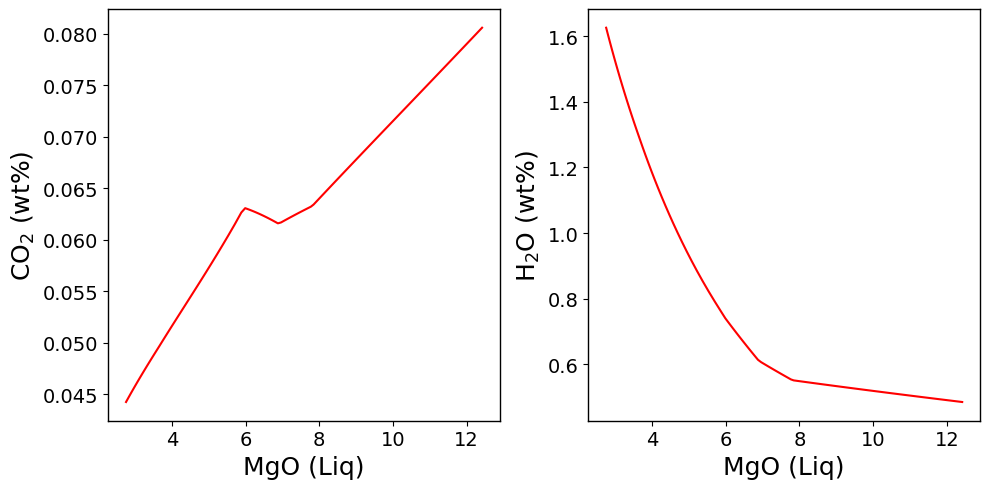

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.plot(Isobaric_Xtal['All']['MgO_Liq'], Isobaric_Xtal['All']['CO2_Liq'], '-r')
ax2.plot(Isobaric_Xtal['All']['MgO_Liq'], Isobaric_Xtal['All']['H2O_Liq'], '-r')

ax1.set_xlabel('MgO (Liq)')
ax2.set_xlabel('MgO (Liq)')

ax1.set_ylabel('CO$_2$ (wt%)')
ax2.set_ylabel('H$_2$O (wt%)')
plt.tight_layout()

### 3d

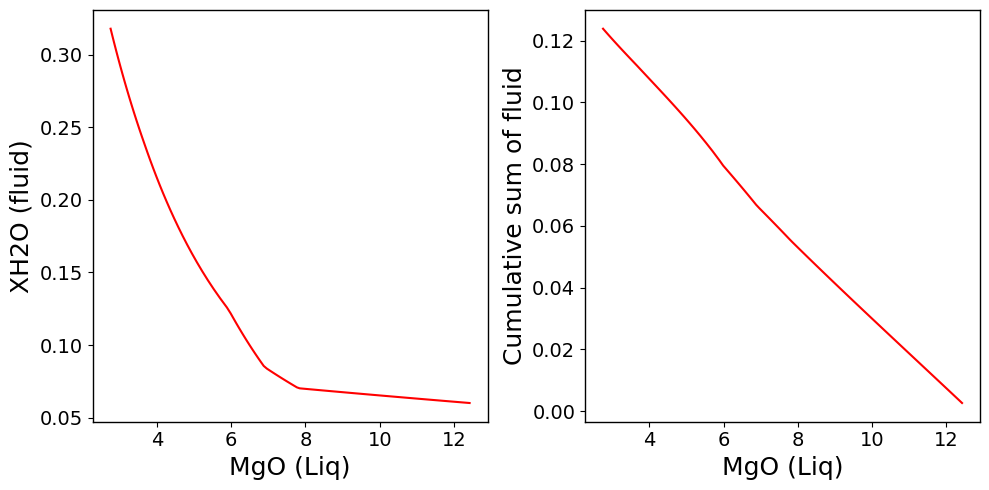

In [19]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))
ax1.plot(Isobaric_Xtal['All']['MgO_Liq'], Isobaric_Xtal['All']['X_H2O_mol_Fl'], '-r')
ax2.plot(Isobaric_Xtal['All']['MgO_Liq'], Isobaric_Xtal['mass_g']['fluid1_cumsum'], '-r')



ax1.set_xlabel('MgO (Liq)')
ax2.set_xlabel('MgO (Liq)')

ax1.set_ylabel('XH2O (fluid)')
ax2.set_ylabel('Cumulative sum of fluid')
plt.tight_layout()

### 3e

In [ ]:
Isobaric_Xtal_keepfluid = ptt.isobaric_crystallisation(Model = "MELTSv1.2.0",
                                           bulk = dict(start_comp_after_ascent),
                                           find_liquidus = True,
                                           P_bar = 1000,
                                           T_end_C = 1050,
                                           dt_C = 2,
                                           fO2_buffer = "FMQ",
                                           fO2_offset = +0.4,
                                           Frac_solid = True,
                                           Frac_fluid = False,
                                          )

A default timeout of 5 minutes has been specified. If you are not getting any results try increasing this using the timeout kwarg.
Running MELTSv1.2.0 calculation... Complete (time taken = 20.19 seconds)

In [21]:
Isobaric_Xtal_keepfluid['mass_g']

,liquid1,fluid1,olivine1,clinopyroxene1,plagioclase1,spinel1,clinopyroxene2,orthopyroxene1,olivine1_cumsum,clinopyroxene1_cumsum,plagioclase1_cumsum,spinel1_cumsum,clinopyroxene2_cumsum,orthopyroxene1_cumsum
0,100.032288,0.002620,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,99.807348,0.003114,0.224234,0.000000,0.000000,0.000000,0.0,0.000000,0.224234,0.000000,0.000000,0.000000,0.000000,0.000000
2,99.572582,0.003627,0.235508,0.000000,0.000000,0.000000,0.0,0.000000,0.459742,0.000000,0.000000,0.000000,0.000000,0.000000
3,99.339536,0.004136,0.233794,0.000000,0.000000,0.000000,0.0,0.000000,0.693537,0.000000,0.000000,0.000000,0.000000,0.000000
4,99.108193,0.004640,0.232097,0.000000,0.000000,0.000000,0.0,0.000000,0.925634,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,31.095125,0.080544,0.000000,0.102330,0.241807,0.080285,0.0,0.046458,13.851894,25.552301,19.144680,7.848351,2.476655,0.611436
118,30.650469,0.081177,0.000000,0.097380,0.235590,0.076593,0.0,0.044862,13.851894,25.649681,19.380270,7.924944,2.476655,0.656298
119,30.221288,0.081800,0.000000,0.092785,0.229638,0.073142,0.0,0.043331,13.851894,25.742466,19.609908,7.998086,2.476655,0.699628
120,29.806730,0.082414,0.000000,0.088514,0.223936,0.069912,0.0,0.041862,13.851894,25.830980,19.833843,8.067998,2.476655,0.741491


Text(0, 0.5, 'Vol% fluid')

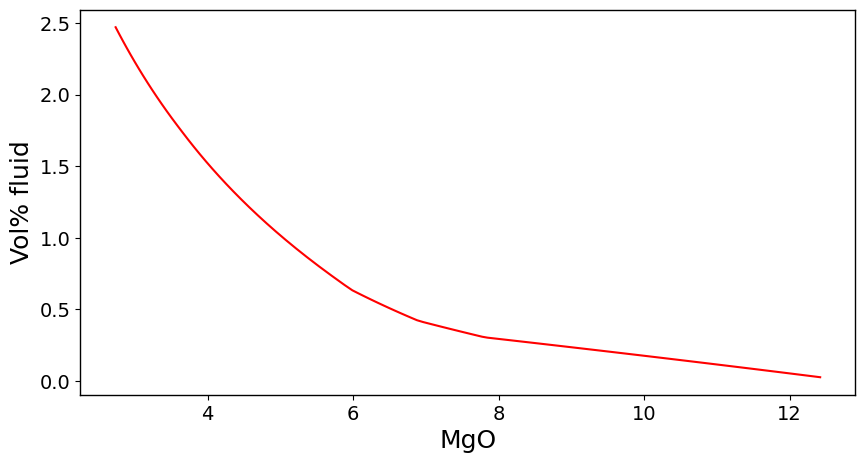

In [ ]:


fig, (ax1) = plt.subplots(1, 1, figsize=(10,5))
ax1.plot(Isobaric_Xtal_keepfluid['All']['MgO_Liq'], 100*Isobaric_Xtal_keepfluid['volume_cm3']['fluid1']/(Isobaric_Xtal_keepfluid['volume_cm3']['liquid1']+Isobaric_Xtal_keepfluid['volume_cm3']['fluid1']), '-r')
ax1.set_xlabel('MgO')
ax1.set_ylabel('Vol% fluid')

## 4. Lets get the magma to decompress up to the surface. 

In [23]:
comp_after_frac=Isobaric_Xtal['liquid1'].iloc[-1] # this grabs the last value after the ascent calculation. 
comp_after_frac

SiO2_Liq      60.760103
TiO2_Liq       1.827489
Al2O3_Liq     12.948337
Cr2O3_Liq      0.000000
Fe2O3_Liq      1.407407
FeO_Liq        4.827693
FeOt_Liq       6.094068
MnO_Liq        0.000000
MgO_Liq        2.754956
CaO_Liq        7.176429
Na2O_Liq       4.232175
K2O_Liq        1.389839
P2O5_Liq       1.005879
H2O_Liq        1.625444
CO2_Liq        0.044251
Fe3Fet_Liq     0.207805
Name: 121, dtype: float64

In [24]:

Kil_decompress_closed= ptt.isothermal_decompression(Model = "MELTSv1.2.0", # rhyolite-MELTS v1.2.0 - updated H2O-CO2 solubility model - This is 'Magmasat' from the lectures
                                            bulk = comp_after_frac, # composition defined above is our starting composition
                                            find_liquidus=True, # specify that we want to start at the liquidus 
                                            fO2_buffer="FMQ", # Impose a fO2 buffer
                                            P_start_bar=1000, # starting pressure (in bars)
                                            P_end_bar=10, # final pressure (in bars)
                                            Frac_fluid=False,
                                            dp_bar=20) # pressure step (in bars)


A default timeout of 5 minutes has been specified. If you are not getting any results try increasing this using the timeout kwarg.
Running MELTSv1.2.0 calculation... Complete (time taken = 9.5 seconds)

### 4b

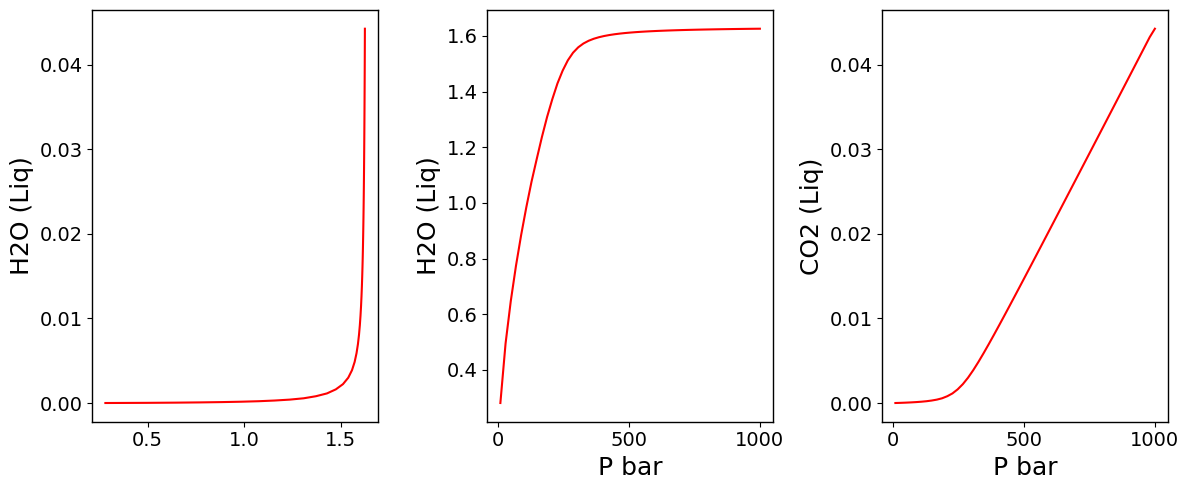

In [25]:
fig, (ax1, ax3, ax2) = plt.subplots(1, 3, figsize=(12,5))
ax1.plot(Kil_decompress_closed['All']['H2O_Liq'], Kil_decompress_closed['All']['CO2_Liq'], '-r')
ax2.plot(Kil_decompress_closed['All']['P_bar'], Kil_decompress_closed['All']['CO2_Liq'], '-r')
ax3.plot(Kil_decompress_closed['All']['P_bar'], Kil_decompress_closed['All']['H2O_Liq'], '-r')
ax1.set_ylabel('H2O (Liq)')
ax2.set_ylabel('CO2 (Liq)')
ax3.set_ylabel('H2O (Liq)')
ax2.set_xlabel('P bar')
ax3.set_xlabel('P bar')
plt.tight_layout()

### 4c

Text(0, 0.5, 'SiO2 Liq')

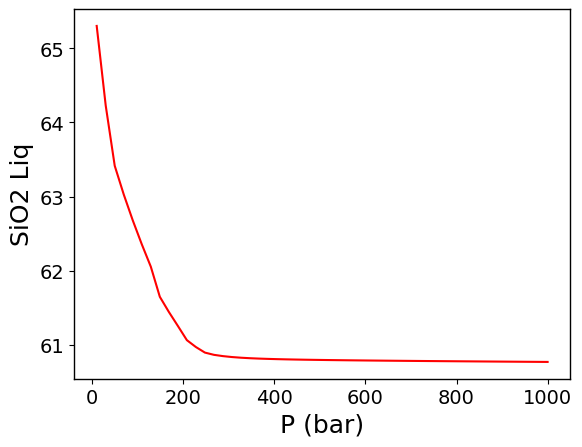

In [26]:
plt.plot(Kil_decompress_closed['All']['P_bar'], Kil_decompress_closed['All']['SiO2_Liq'], '-r')
plt.xlabel('P (bar)')
plt.ylabel('SiO2 Liq')

In [28]:
Kil_decompress_closed['PhaseList'].unique()

array(['Liq', 'Liq,Fl', 'Liq,Fl,Plag', 'Liq,Fl,Plag,Opx',
       'Liq,Fl,Plag,Opx,Rhm', 'Liq,Fl,Plag,Opx,Rhm,Cpx,whitlockite1'],
      dtype=object)

In [29]:
Kil_decompress_closed['mass_g'].tail()

,liquid1,fluid1,plagioclase1,orthopyroxene1,rhm-oxide1,clinopyroxene1,whitlockite1
46,83.581282,0.930426,11.745409,3.343852,0.373364,0.000000,0.00000
47,80.614641,1.046223,13.872037,3.988607,0.450996,0.000000,0.00000
48,77.384118,1.169244,16.195952,4.690317,0.530724,0.000000,0.00000
49,72.787417,1.309525,18.806388,4.896597,0.697985,1.260168,0.20984
50,66.985188,1.481572,22.334530,5.338085,0.884301,2.475238,0.46505


(array([3., 1., 2., 1., 1., 2., 1., 0., 1., 1.]),
 array([54.20414631, 54.57766589, 54.95118548, 55.32470507, 55.69822465,
        56.07174424, 56.44526382, 56.81878341, 57.19230299, 57.56582258,
        57.93934217]),
 <BarContainer object of 10 artists>)

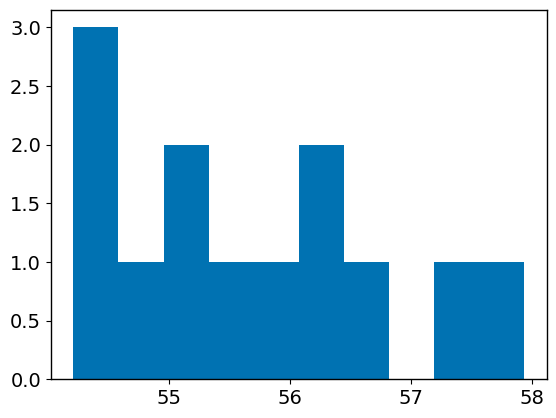

In [30]:
plt.hist(Kil_decompress_closed['plagioclase1']['SiO2_Plag'])

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([50.63342975, 50.64085568, 50.64828161, 50.65570754, 50.66313347,
        50.67055939, 50.67798532, 50.68541125, 50.69283718, 50.70026311,
        50.70768904]),
 <BarContainer object of 10 artists>)

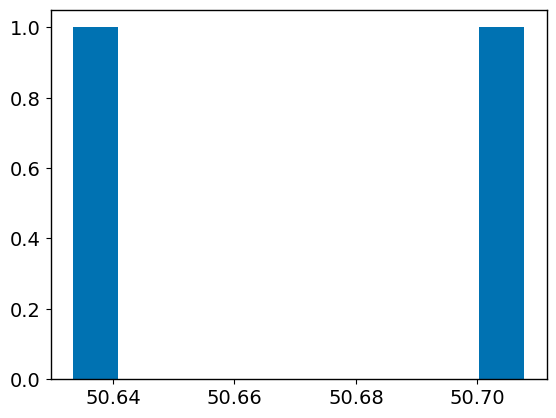

In [31]:
plt.hist(Kil_decompress_closed['clinopyroxene1']['SiO2_Cpx'])

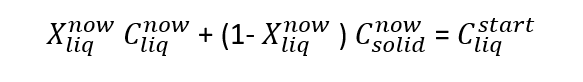

### 4e

Text(0, 0.5, 'Vol% fluid')

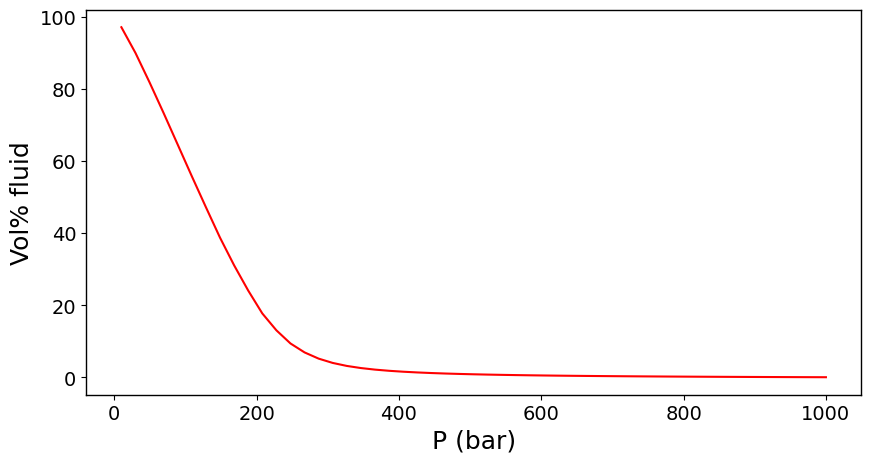

In [32]:


fig, (ax1) = plt.subplots(1, 1, figsize=(10,5))
ax1.plot(Kil_decompress_closed['All']['P_bar'], 100*Kil_decompress_closed['volume_cm3']['fluid1']/(Kil_decompress_closed['volume_cm3']['liquid1']+Kil_decompress_closed['volume_cm3']['fluid1']), '-r')
ax1.set_xlabel('P (bar)')
ax1.set_ylabel('Vol% fluid')